In [11]:
import pandas as pd

df = pd.read_csv("Hospital.csv")


In [12]:
print(df.head())
print(df.info)
print(df.describe())

                             Patient ID                   Name Date of Birth  \
0  921d93d1-17b8-426f-abae-5b16c7e5cd93         Debra Griffith    1971-04-01   
1  c3e70ecd-b794-4e9e-8136-ccf4ff363fe0            Robert Ross    1957-02-20   
2  ef85177f-f933-4f60-aefe-6979e35c709a           Rachel Perez    1987-11-27   
3  8e36ba50-ebde-4b68-81b9-3cdca0b7eade       Michael Williams    2021-12-06   
4  422bd94a-41e1-4bdc-96a3-f7570a868df1  Christopher Rodriguez    1990-12-19   

   Gender                      Medical Condition              Treatments  \
0  Female  Chronic Obstructive Pulmonary Disease              Medication   
1  Female                               Migraine  Pain Relief Medication   
2  Female                Urinary Tract Infection               Hydration   
3    Male                                 Stroke        Physical Therapy   
4    Male                           Hypertension       Lifestyle Changes   

                                      Doctor's Notes  Admit Da

In [13]:

df=df.dropna()

In [14]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Patient ID           0
Name                 0
Date of Birth        0
Gender               0
Medical Condition    0
Treatments           0
Doctor's Notes       0
Admit Date           0
Discharge Date       0
Bill Amount          0
dtype: int64


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [16]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [17]:

print("\nFeature Columns:")
print(X.columns)



Feature Columns:
Index(['Patient ID', 'Name', 'Date of Birth', 'Gender', 'Medical Condition',
       'Treatments', 'Doctor's Notes', 'Admit Date', 'Discharge Date'],
      dtype='object')


In [18]:

print("\nTarget Column:")
print(y.name)


Target Column:
Bill Amount


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
import warnings

warnings.filterwarnings("ignore")

In [36]:
sample = X.iloc[0].values.reshape(1, -1)
print("Custom Prediction:", model.predict(sample))

Custom Prediction: [10647.45205663]


In [37]:
y_pred = model.predict(X_test)

In [38]:
if'key' in df.columns:
    df=df.drop('key',axis=1)

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 177345432.13218004
R2 Score: 0.004822253435492585


In [40]:
Q1 = df['Bill Amount'].quantile(0.25)
Q3 = df['Bill Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Bill Amount'] < lower_bound) | (df['Bill Amount'] > upper_bound)]

print(outliers)

     Patient ID  Name  Date of Birth  Gender  Medical Condition  Treatments  \
10          539   149            585       0                  8           8   
17          566   908            535       0                  8          28   
34           13   545            182       1                  8          28   
37          270   503            226       1                  7           3   
38          108   654            183       1                  9          13   
..          ...   ...            ...     ...                ...         ...   
912         986   705            111       1                  7           3   
941         665   351            683       1                 17          21   
945         124   238            859       1                 17          21   
977         844   417            634       0                  8          32   
980         691   923            785       1                  9          21   

     Doctor's Notes  Admit Date  Discharge Date  Bi

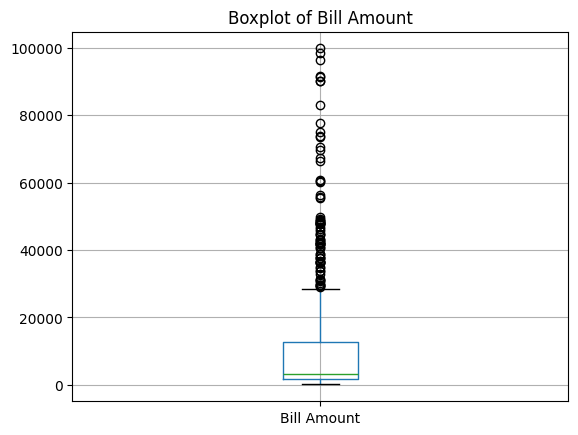

In [41]:
import matplotlib.pyplot as plt
df.boxplot(column='Bill Amount')
plt.title("Boxplot of Bill Amount")
plt.show()

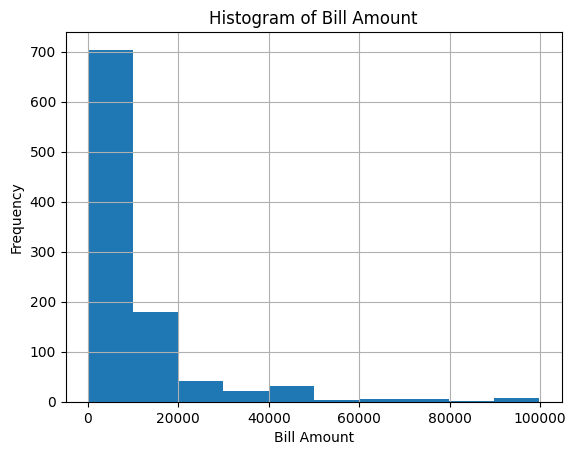

In [42]:
df['Bill Amount'].hist()
plt.title("Histogram of Bill Amount")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.show()

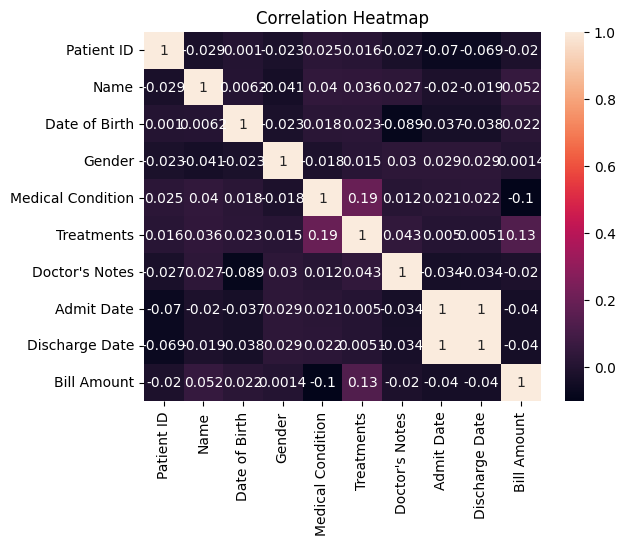

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()